# Heart Disease EDA & Visualization
### CodeAlpha Data Analytics Internship — Task 2 & 3

This notebook explores the UCI Heart Disease dataset (920 patient records) to identify 
patterns related to age, cholesterol, chest pain type, and other clinical factors 
associated with heart disease. The goal is to understand which features show the 
strongest relationship with heart disease presence.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [49]:
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [50]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [51]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [52]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [53]:
print("Rows where cholesterol is 0:", (df['chol'] == 0).sum())
print("Rows where resting blood pressure is 0:", (df['trestbps'] == 0).sum())

Rows where cholesterol is 0: 172
Rows where resting blood pressure is 0: 1


In [54]:
df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)

print("Missing values now in chol:", df['chol'].isnull().sum())
print("Missing values now in trestbps:", df['trestbps'].isnull().sum())

Missing values now in chol: 202
Missing values now in trestbps: 60


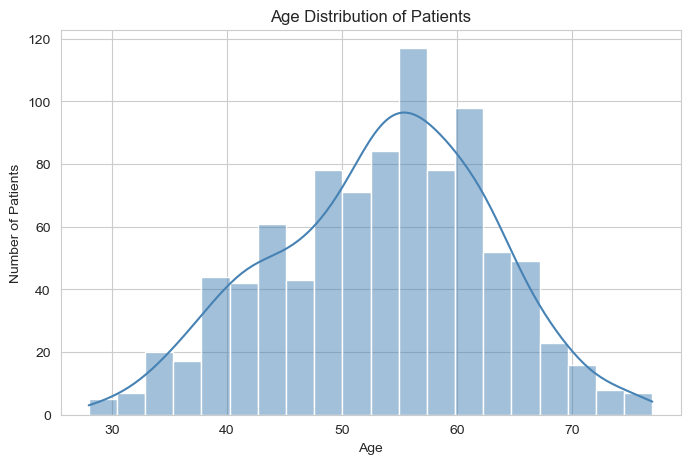

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

Most patients are between 45 and 65 years old, with a peak around the mid-50s. 
Very few patients are under 30 or over 75.

In [56]:
df['has_disease'] = df['num'].apply(lambda x: 'Yes' if x > 0 else 'No')
df['has_disease'].value_counts()

has_disease
Yes    509
No     411
Name: count, dtype: int64

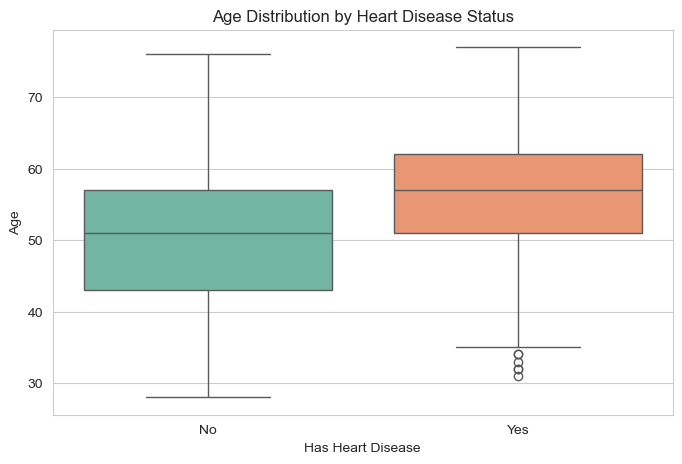

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(x='has_disease', y='age', data=df, hue='has_disease', palette='Set2', legend=False)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Has Heart Disease")
plt.ylabel("Age")
plt.show()

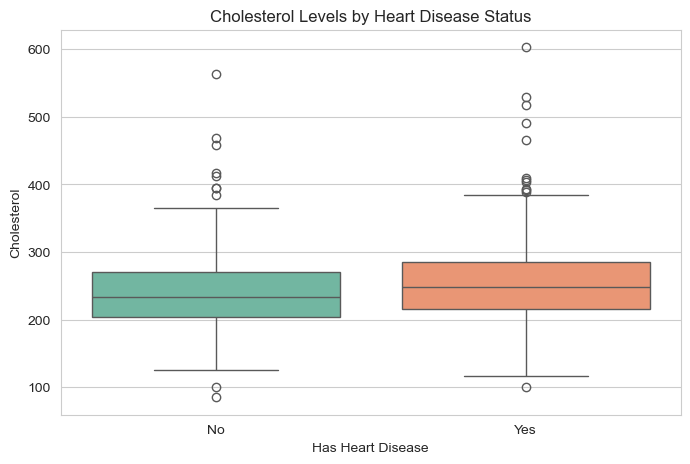

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(x='has_disease', y='chol', data=df, hue='has_disease', palette='Set2', legend=False)
plt.title("Cholesterol Levels by Heart Disease Status")
plt.xlabel("Has Heart Disease")
plt.ylabel("Cholesterol")
plt.show()

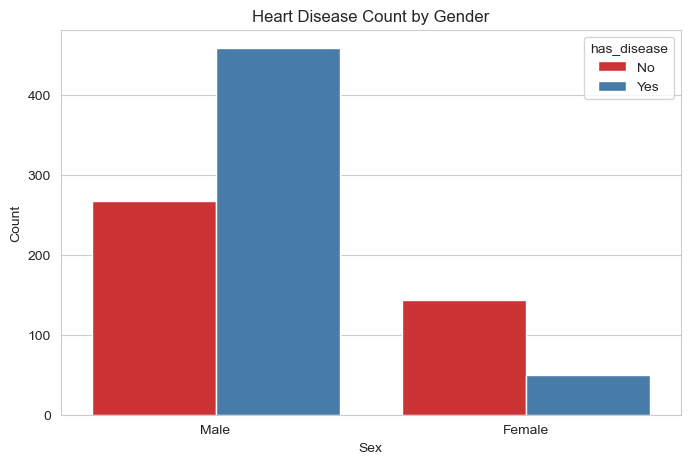

In [59]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='has_disease', data=df, palette='Set1')
plt.title("Heart Disease Count by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

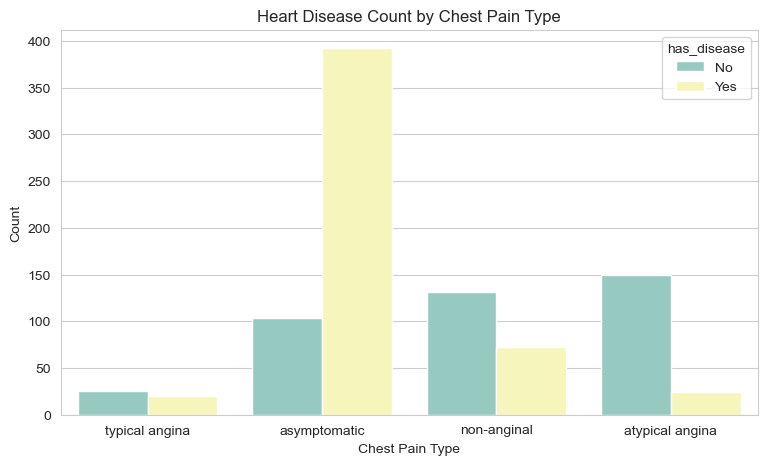

In [60]:
plt.figure(figsize=(9,5))
sns.countplot(x='cp', hue='has_disease', data=df, palette='Set3')
plt.title("Heart Disease Count by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

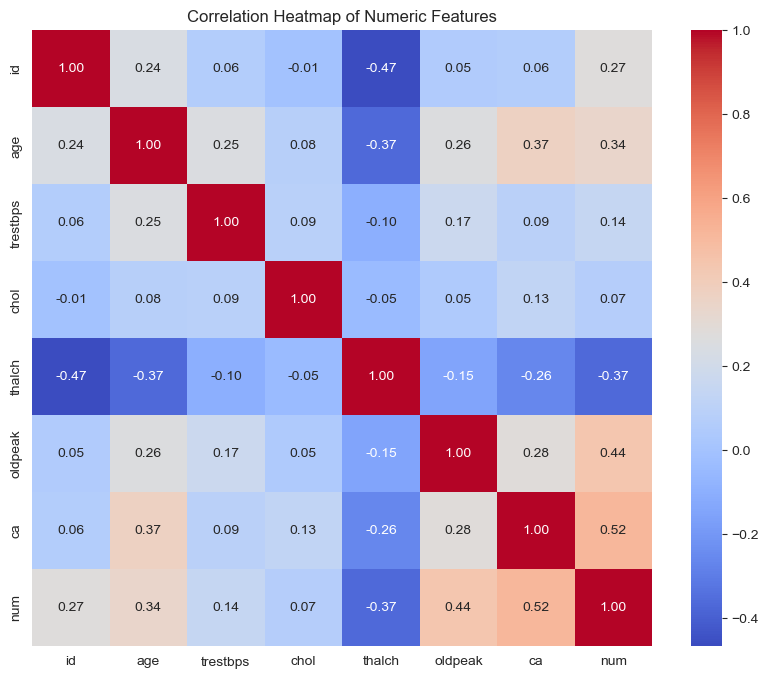

In [61]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [62]:
df.groupby('has_disease')[['age', 'chol', 'trestbps', 'thalch']].mean()

,age,chol,trestbps,thalch
has_disease,,,,
No,50.547445,240.158602,129.913043,148.800512
Yes,55.903733,254.008671,134.264392,128.261603


## Conclusion

Based on this exploratory analysis of the UCI Heart Disease dataset:

- **Age**: Patients with heart disease tend to be slightly older on average than those without (56 vs. 51 years).
- **Chest Pain Type**: Certain chest pain types are much more strongly associated with heart disease than others, making it one of the more useful indicators in this dataset.
- **Gender**: Men appear more frequently affected by heart disease than women in this dataset.
- **Cholesterol**: Patients with heart disease had slightly higher average cholesterol (254 vs. 240), but the difference is fairly modest, suggesting cholesterol alone isn't a strong standalone predictor here.
- **Max Heart Rate (thalch)**: Patients with heart disease had a noticeably *lower* average maximum heart rate (128 vs. 149), consistent with medical understanding that reduced heart rate response can indicate cardiac issues.
- **Data Quality**: Several columns (`ca`, `thal`, `slope`, `chol`, `trestbps`) had missing or invalid (zero) values that were identified and cleaned during this analysis — an important step before drawing conclusions from any dataset.

Overall, this analysis highlights how a combination of demographic (age, sex) and clinical 
(chest pain type, cholesterol, max heart rate) features can help identify patterns associated 
with heart disease risk.